<a href="https://colab.research.google.com/github/farahwadya/how-did-House-prices-in-US-by-change-date/blob/main/Gridsearch_SARIMA_Models_(Core).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# upload pckage

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter
import statsmodels.tsa.api as tsa
import os
!pip install pmdarima
import pmdarima as pm
from pmdarima.arima.utils import ndiffs, nsdiffs
from pmdarima.model_selection import train_test_split


# Set wide fig size for plots
plt.rcParams['figure.figsize']=(12,3)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# custom function

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import statsmodels.tsa.api as tsa
def get_sig_lags(ts, type='ACF',  nlags=None,alpha=0.5):


    if type == 'ACF':
        # Running the function used by plot_acf
        corr_values, conf_int = tsa.stattools.acf(ts, alpha=alpha, nlags=nlags)

    elif type=='PACF':
        corr_values, conf_int = tsa.stattools.pacf(ts, alpha=alpha, nlags=nlags)

    else:
        raise Exception("type must be either 'ACF' or 'PACF'")

    # Determine lags
    lags =range(len(corr_values))

    # Create a centered version of the acf_df
    corr_df = pd.DataFrame({type:corr_values,
                            'Lags':lags,
                            'lower ci': conf_int[:,0]-corr_values, # subtract acf from lower ci to center
                            'upper ci': conf_int[:,1]-corr_values, # subtact acf to upper ci to center
                                 })
    corr_df = corr_df.set_index("Lags")

    # Getting filter for sig lags
    filter_sig_lags = (corr_df[type] < corr_df['lower ci']) | (corr_df[type] > corr_df['upper ci'])

    # Get lag #'s
    sig_lags= corr_df.index[filter_sig_lags]
    sig_lags = sig_lags[sig_lags!=0]

    return sig_lags
def plot_acf_pacf(ts, nlags=40, figsize=(10, 5),
                  annotate_sig=False, alpha=.05,
                 acf_kws={}, pacf_kws={},
                  annotate_seas=False, m = None,
                 seas_color='black'):

    fig, axes = plt.subplots(nrows=2, figsize=figsize)


    # Sig lags line style
    sig_vline_kwargs = dict( ls=':', lw=1, zorder=0, color='red')

    # ACF
    tsa.graphics.plot_acf(ts, ax=axes[0], lags=nlags, **acf_kws)

    ## Annotating sig acf lags
    if annotate_sig == True:
        sig_acf_lags = get_sig_lags(ts,nlags=nlags,alpha=alpha, type='ACF')
        for lag in sig_acf_lags:
            axes[0].axvline(lag,label='sig', **sig_vline_kwargs )

    # PACF
    tsa.graphics.plot_pacf(ts,ax=axes[1], lags=nlags, **pacf_kws)

    ## Annotating sig pacf lags
    if annotate_sig == True:
        ## ANNOTATING SIG LAGS
        sig_pacf_lags = get_sig_lags(ts,nlags=nlags,alpha=alpha, type='PACF')
        for lag in sig_pacf_lags:
            axes[1].axvline(lag, label='sig', **sig_vline_kwargs)




    ### ANNOTATE SEASONS
    if annotate_seas == True:
        # Ensure m was defined
        if m is None:
            raise Exception("Must define value of m if annotate_seas=True.")

        ## Calculate number of complete seasons to annotate
        n_seasons = nlags//m

        # Seasonal Lines style
        seas_vline_kwargs = dict( ls='--',lw=1, alpha=.7, color=seas_color, zorder=-1)

        ## for each season, add a line
        for i in range(1, n_seasons+1):
            axes[0].axvline(m*i, **seas_vline_kwargs, label="season")
            axes[1].axvline(m*i, **seas_vline_kwargs, label="season")

    fig.tight_layout()

    return fig

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
def regression_metrics_ts(ts_true, ts_pred, label="", verbose=True, output_dict=False,):
    # Get metrics
    mae = mean_absolute_error(ts_true, ts_pred)
    mse = mean_squared_error(ts_true, ts_pred)
    rmse=np.sqrt(mse)
   # rmse = mean_squared_error(ts_true, ts_pred, squared=False)
    r_squared = r2_score(ts_true, ts_pred)
    mae_perc = mean_absolute_percentage_error(ts_true, ts_pred) * 100
    if verbose == True:
        # Print Result with label
        header = "---" * 20
        print(header, f"Regression Metrics: {label}", header, sep="\n")
        print(f"- MAE = {mae:,.3f}")
        print(f"- MSE = {mse:,.3f}")
        print(f"- RMSE = {rmse:,.3f}")
        print(f"- R^2 = {r_squared:,.3f}")
        print(f"- MAPE = {mae_perc:,.2f}%")
    if output_dict == True:
        metrics = {
            "Label": label,
            "MAE": mae,
            "MSE": mse,
            "RMSE": rmse,
            "R^2": r_squared,
            "MAPE(%)": mae_perc,
        }
        return metrics

In [ ]:

# Custom function for Ad Fuller Test
def get_adfuller_results(ts, alpha=.05, label='adfuller', **kwargs): #kwargs for adfuller()
    # Saving each output
    (test_stat, pval, nlags, nobs, crit_vals_d,
    icbest ) = tsa.adfuller(ts, **kwargs)
    # Converting output to a dictionary with the interpretation of p
    adfuller_results = {'Test Statistic': test_stat,
                        "# of Lags Used":nlags,
                       '# of Observations':nobs,
                        'p-value': round(pval,6),
                        'alpha': alpha,
                       'sig/stationary?': pval < alpha}
    return pd.DataFrame(adfuller_results, index =[label])

In [ ]:
def plot_forecast(ts_train, ts_test, forecast_df, n_train_lags=None,
                  figsize=(10,4), title='Comparing Forecast vs. True Data'):
    ### PLot training data, and forecast (with upper/,lower ci)
    fig, ax = plt.subplots(figsize=figsize)

    # setting the number of train lags to plot if not specified
    if n_train_lags==None:
        n_train_lags = len(ts_train)

    # Plotting Training  and test data
    ts_train.iloc[-n_train_lags:].plot(ax=ax, label="train")
    ts_test.plot(label="test", ax=ax)

    # Plot forecast
    forecast_df['mean'].plot(ax=ax, color='green', label="forecast")

    # Add the shaded confidence interval
    ax.fill_between(forecast_df.index,
                    forecast_df['mean_ci_lower'],
                   forecast_df['mean_ci_upper'],
                   color='green', alpha=0.3,  lw=2)

    # set the title and add legend
    ax.set_title(title)
    ax.legend();

    return fig, ax

In [ ]:
fpath='/content/drive/MyDrive/AXSOSACADEMY/06-AdvancedML/Week21/Data/City_zhvi_uc_sfrcondo_tier_0.33_0.67_sm_sa_month - City_zhvi_uc_sfrcondo_tier_0.33_0.67_sm_sa_month.csv'
df=pd.read_csv(fpath)
df.head()

,RegionID,SizeRank,RegionName,RegionType,StateName,State,Metro,CountyName,2000-01-31,2000-02-29,...,2021-12-31,2022-01-31,2022-02-28,2022-03-31,2022-04-30,2022-05-31,2022-06-30,2022-07-31,2022-08-31,2022-09-30
0,6181,0,New York,city,NY,NY,"New York-Newark-Jersey City, NY-NJ-PA",Queens County,253690.0,255517.0,...,741586.0,745686.0,750578.0,756734.0,762321.0,768797.0,773944.0,777692.0,779960.0,781622.0
1,12447,1,Los Angeles,city,CA,CA,"Los Angeles-Long Beach-Anaheim, CA",Los Angeles County,234181.0,234401.0,...,924019.0,928991.0,937936.0,953874.0,973168.0,990391.0,992337.0,992630.0,978196.0,966595.0
2,39051,2,Houston,city,TX,TX,"Houston-The Woodlands-Sugar Land, TX",Harris County,109068.0,109079.0,...,245783.0,248718.0,252080.0,256435.0,261101.0,265558.0,268901.0,271059.0,272400.0,272639.0
3,17426,3,Chicago,city,IL,IL,"Chicago-Naperville-Elgin, IL-IN-WI",Cook County,166139.0,166536.0,...,302821.0,305104.0,306404.0,308303.0,309649.0,312487.0,314663.0,315910.0,315587.0,315429.0
4,6915,4,San Antonio,city,TX,TX,"San Antonio-New Braunfels, TX",Bexar County,114794.0,114975.0,...,269323.0,274032.0,278464.0,284127.0,289739.0,294776.0,297727.0,298796.0,299124.0,298951.0


In [ ]:
df.isnull().sum().sum()

np.int64(1754072)

In [ ]:
df.duplicated().sum()

np.int64(0)

# Filter the 4 largest cities into a new dataframe.


In [ ]:
lrg_city=df[df['SizeRank']<4]
lrg_city.head()

,RegionID,SizeRank,RegionName,RegionType,StateName,State,Metro,CountyName,2000-01-31,2000-02-29,...,2021-12-31,2022-01-31,2022-02-28,2022-03-31,2022-04-30,2022-05-31,2022-06-30,2022-07-31,2022-08-31,2022-09-30
0,6181,0,New York,city,NY,NY,"New York-Newark-Jersey City, NY-NJ-PA",Queens County,253690.0,255517.0,...,741586.0,745686.0,750578.0,756734.0,762321.0,768797.0,773944.0,777692.0,779960.0,781622.0
1,12447,1,Los Angeles,city,CA,CA,"Los Angeles-Long Beach-Anaheim, CA",Los Angeles County,234181.0,234401.0,...,924019.0,928991.0,937936.0,953874.0,973168.0,990391.0,992337.0,992630.0,978196.0,966595.0
2,39051,2,Houston,city,TX,TX,"Houston-The Woodlands-Sugar Land, TX",Harris County,109068.0,109079.0,...,245783.0,248718.0,252080.0,256435.0,261101.0,265558.0,268901.0,271059.0,272400.0,272639.0
3,17426,3,Chicago,city,IL,IL,"Chicago-Naperville-Elgin, IL-IN-WI",Cook County,166139.0,166536.0,...,302821.0,305104.0,306404.0,308303.0,309649.0,312487.0,314663.0,315910.0,315587.0,315429.0


In [ ]:
df.columns

Index(['RegionID', 'SizeRank', 'RegionName', 'RegionType', 'StateName',
       'State', 'Metro', 'CountyName', '2000-01-31', '2000-02-29',
       ...
       '2021-12-31', '2022-01-31', '2022-02-28', '2022-03-31', '2022-04-30',
       '2022-05-31', '2022-06-30', '2022-07-31', '2022-08-31', '2022-09-30'],
      dtype='object', length=281)

In [ ]:
lrg_city.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4 entries, 0 to 3
Columns: 281 entries, RegionID to 2022-09-30
dtypes: float64(273), int64(2), object(6)
memory usage: 8.8+ KB


In [ ]:
df_long=pd.melt(lrg_city,id_vars=['RegionID', 'SizeRank', 'RegionName', 'RegionType', 'StateName',
       'State', 'Metro', 'CountyName'], var_name='Date', value_name='Population')

In [ ]:
df_long['Date'] = pd.to_datetime(df_long['Date'])
df_long.set_index('Date', inplace=True)

In [ ]:
# Resample the dataframe as monthly frequency, grouped by City.
df_monthly=df_long.groupby('RegionName').resample('M').sum()
df_monthly

/tmp/ipython-input-1423192828.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_monthly=df_long.groupby('RegionName').resample('M').sum()


RegionID  SizeRank RegionName RegionType StateName  \
RegionName Date                                                             
Chicago    2000-01-31     17426         3    Chicago       city        IL   
           2000-02-29     17426         3    Chicago       city        IL   
           2000-03-31     17426         3    Chicago       city        IL   
           2000-04-30     17426         3    Chicago       city        IL   
           2000-05-31     17426         3    Chicago       city        IL   
...                         ...       ...        ...        ...       ...   
New York   2022-05-31      6181         0   New York       city        NY   
           2022-06-30      6181         0   New York       city        NY   
           2022-07-31      6181         0   New York       city        NY   
           2022-08-31      6181         0   New York       city        NY   
           2022-09-30      6181         0   New York       city        NY   

                      State                                  Metro  \
RegionName Date                                                      
Chicago    2000-01-31    IL     Chicago-Naperville-Elgin, IL-IN-WI   
           2000-02-29    IL     Chicago-Naperville-Elgin, IL-IN-WI   
           2000-03-31    IL     Chicago-Naperville-Elgin, IL-IN-WI   
           2000-04-30    IL     Chicago-Naperville-Elgin, IL-IN-WI   
           2000-05-31    IL     Chicago-Naperville-Elgin, IL-IN-WI   
...                     ...                                    ...   
New York   2022-05-31    NY  New York-Newark-Jersey City, NY-NJ-PA   
           2022-06-30    NY  New York-Newark-Jersey City, NY-NJ-PA   
           2022-07-31    NY  New York-Newark-Jersey City, NY-NJ-PA   
           2022-08-31    NY  New York-Newark-Jersey City, NY-NJ-PA   
           2022-09-30    NY  New York-Newark-Jersey City, NY-NJ-PA   

                          CountyName  Population  
RegionName Date                                   
Chicago    2000-01-31    Cook County    166139.0  
           2000-02-29    Cook County    166536.0  
           2000-03-31    Cook County    167368.0  
           2000-04-30    Cook County    168826.0  
           2000-05-31    Cook County    170499.0  
...                              ...         ...  
New York   2022-05-31  Queens County    768797.0  
           2022-06-30  Queens County    773944.0  
           2022-07-31  Queens County    777692.0  
           2022-08-31  Queens County    779960.0  
           2022-09-30  Queens County    781622.0  

[1092 rows x 9 columns]

In [ ]:
df_long.head()

,RegionID,SizeRank,RegionName,RegionType,StateName,State,Metro,CountyName,Population
Date,,,,,,,,,
2000-01-31,6181,0,New York,city,NY,NY,"New York-Newark-Jersey City, NY-NJ-PA",Queens County,253690.0
2000-01-31,12447,1,Los Angeles,city,CA,CA,"Los Angeles-Long Beach-Anaheim, CA",Los Angeles County,234181.0
2000-01-31,39051,2,Houston,city,TX,TX,"Houston-The Woodlands-Sugar Land, TX",Harris County,109068.0
2000-01-31,17426,3,Chicago,city,IL,IL,"Chicago-Naperville-Elgin, IL-IN-WI",Cook County,166139.0
2000-02-29,6181,0,New York,city,NY,NY,"New York-Newark-Jersey City, NY-NJ-PA",Queens County,255517.0


# Part 2

In [ ]:
def thousands(x,pos):
  new_x=x/1000
  return f'{new_x:,.0f}k'
fmt_thousands=FuncFormatter(thousands)

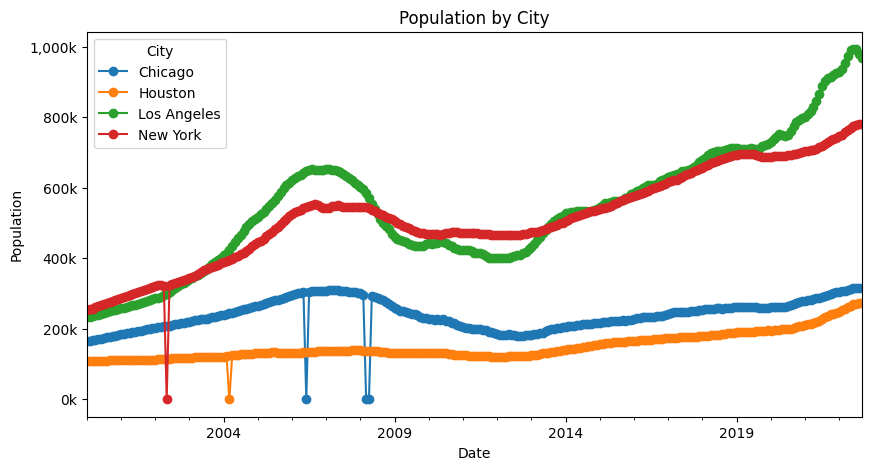

In [ ]:
#Plot the home values for all 4 cities.
df_unstacked=df_monthly['Population'].unstack(level=0) # level=1, return it to nearly wide form data
plot= df_unstacked.plot(figsize=(10,5),marker='o')
plot.set_xlabel('Date')
plot.yaxis.set_major_formatter(fmt_thousands)
plot.set_ylabel('Population')
plot.set_title('Population by City')
plt.legend(title='City')
plt.show()


In [ ]:
df_diff = df_unstacked.diff()
change_dec = df_diff.loc['2008-12-31']
print(change_dec)


RegionName
Chicago        -5753.0
Houston         -964.0
Los Angeles   -12611.0
New York       -4458.0
Name: 2008-12-31 00:00:00, dtype: float64


1) Which City had the highest Typical Home Value at the end of 2008? Which had the least?
`Chicago`
2) How much did the home values change from November 2008 to December 2008 (in dollars)?
- it all decreases
RegionName
Chicago  the price decrease by -5753.0 dollars
Houston the price decrease by -964.0 dollars
Los Angeles the price decrease by  -12611.0 dollars
New York the price decrease by -4458.0 dollars

### additional question to understand the data

In [ ]:

df_unstacked = df_unstacked.sort_index()

# change for each city
change_per_city = df_unstacked.iloc[-1] - df_unstacked.iloc[0]

# city with highest price
max_city = change_per_city.idxmax()
max_change = change_per_city.max()

print(f"The city with the highest price increase is {max_city} with a change of ${max_change:,.0f}")



The city with the highest price increase is Los Angeles with a change of $732,414


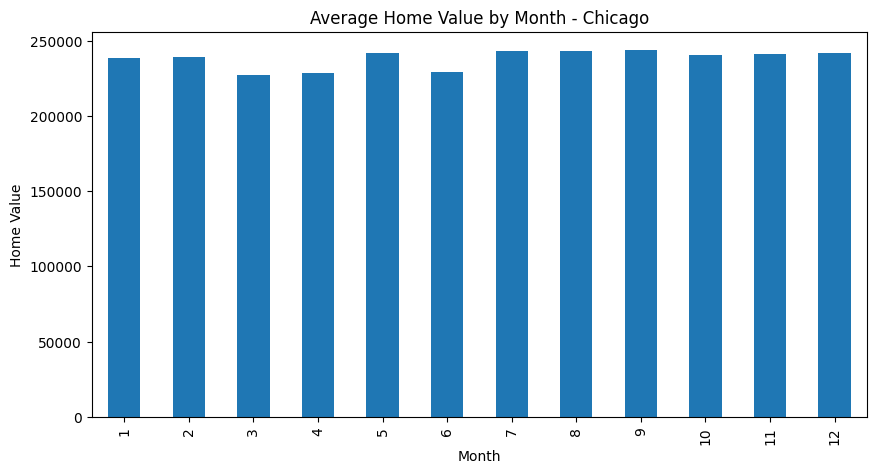

In [ ]:

df_unstacked['Month'] = df_unstacked.index.month

# claculate avg
monthly_avg = df_unstacked.groupby('Month')['Chicago'].mean()

# plot monthly avg
monthly_avg.plot(kind='bar', figsize=(10,5))
plt.title('Average Home Value by Month - Chicago')
plt.ylabel('Home Value')
plt.show()


# Gridsearch SARIMA excersice

# modeling

In [ ]:
#max city at 2008
last_2008 = df_unstacked.loc['2008-12-31']
max_city = last_2008.idxmax()
print(max_city)


New York


In [ ]:
df2018=df_long[df_long.index.year>=2018]
df2018.head()
ts=df2018[df2018['RegionName']==max_city]['Population']
ts=ts.sort_index()
ts.head()

,Population
Date,
2018-01-31,656700.0
2018-02-28,661012.0
2018-03-31,665672.0
2018-04-30,669989.0
2018-05-31,673514.0


In [ ]:
ts.asfreq('M')

/tmp/ipython-input-3927280258.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  ts.asfreq('M')


,Population
Date,
2018-01-31,656700.0
2018-02-28,661012.0
2018-03-31,665672.0
2018-04-30,669989.0
2018-05-31,673514.0
2018-06-30,676434.0
2018-07-31,678984.0
2018-08-31,681140.0
2018-09-30,683546.0


<Axes: xlabel='Date'>

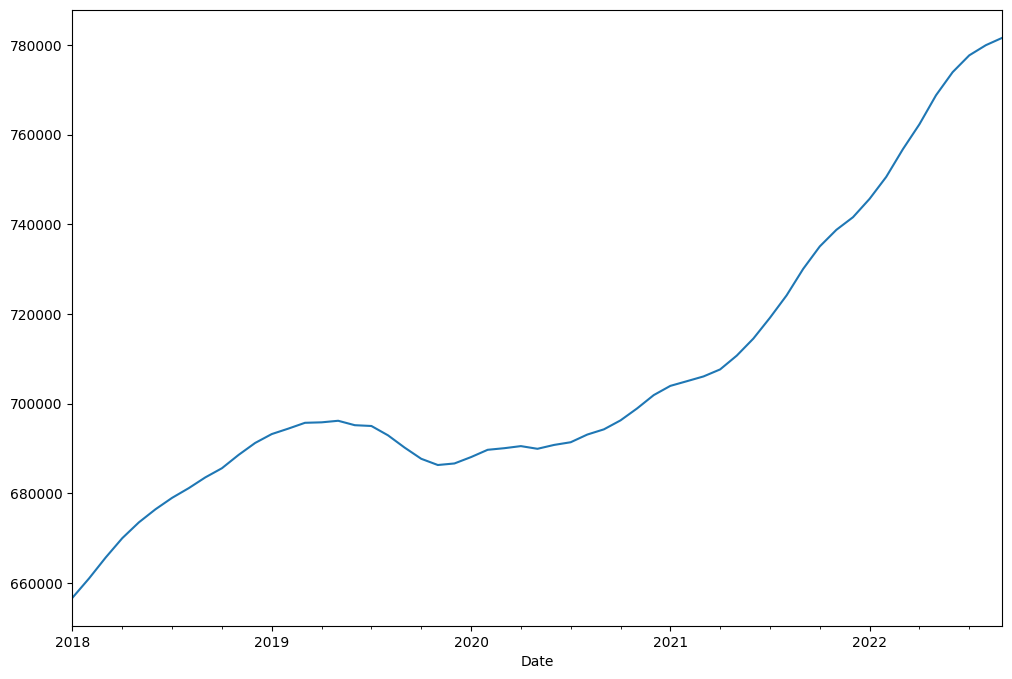

In [ ]:
ts.plot(figsize=(12,8))

In [ ]:
#checking for null values
ts.isnull().sum()

np.int64(0)

## check for seasonality

In [ ]:
print(ts.index[:12])


DatetimeIndex(['2018-01-31', '2018-02-28', '2018-03-31', '2018-04-30',
               '2018-05-31', '2018-06-30', '2018-07-31', '2018-08-31',
               '2018-09-30', '2018-10-31', '2018-11-30', '2018-12-31'],
              dtype='datetime64[ns]', name='Date', freq=None)


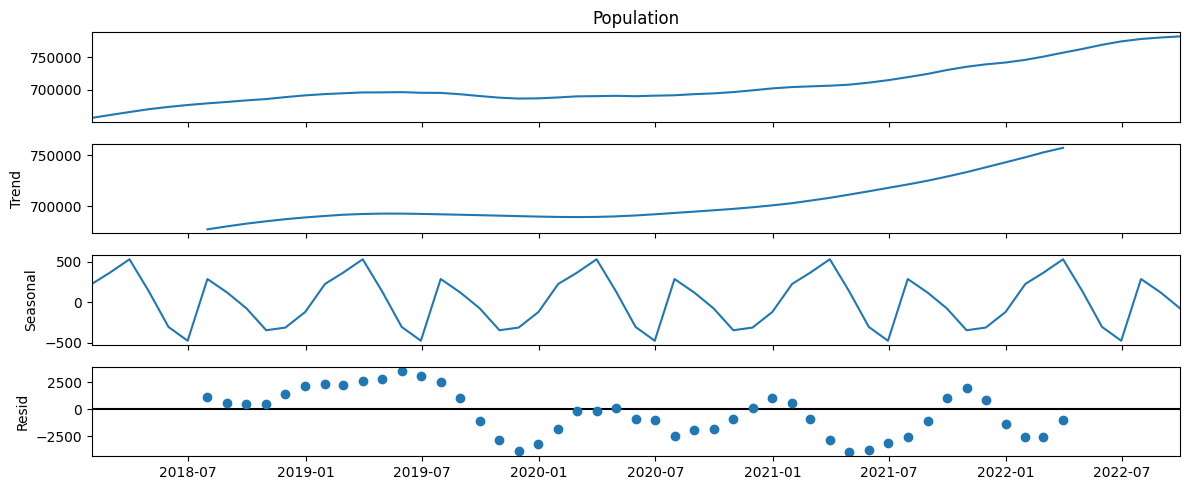

In [ ]:
# Decompose the Time series to detect seasonality and decide if your model should or should not have a seasonal component
decomp=tsa.seasonal_decompose(ts)
fig = decomp.plot()
fig.set_size_inches(12,5)
fig.tight_layout()


In [ ]:
# How big is the seasonal component
seasonal_delta = decomp.seasonal.max() - decomp.seasonal.min()
# How big is the seasonal component relative to the time series?
print(f"The seasonal component is {seasonal_delta: .2f} which is ~{seasonal_delta/(ts.max()-ts.min()) * 100 :.2f}% of the variation in time series.")

The seasonal component is  1006.13 which is ~0.81% of the variation in time series.


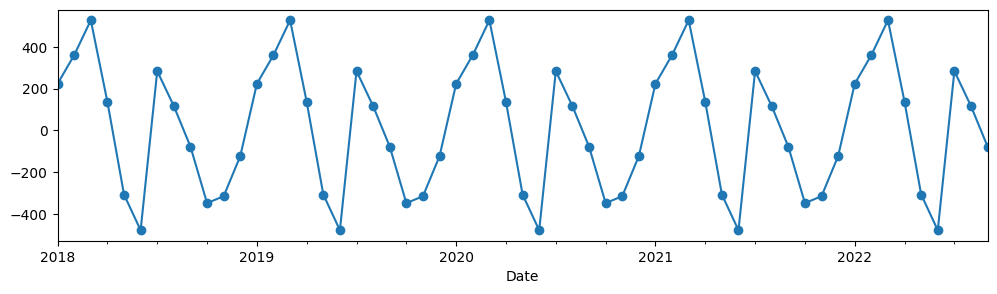

In [ ]:
# Narrow down the date range of the plot
seasonal = decomp.seasonal
ax = seasonal.loc['2018':].plot(marker = 'o') # from the plot we can see that m=12

Observation: Clear seasonal pattern visually.

Scale Check: Seasonal impact is only ±500 units.

Conclusion: Seasonality is insignificant relative to the Trend and Residuals (Noise).

## stationarity

In [ ]:
#Determine Time Series Model Orders
#Check the time series for stationarity.
#Determine the number of differencing needed to make the data stationary
#Check the ACF/PACF Plots of the differenced data to determine the orders
# determine d
d = ndiffs(ts)
print (f'd = {d}')
# determine D
D = nsdiffs(ts, m = 12) # m=12 as the decomp plot indicates that the scale is repeating every 12 month 'no seasonality at this data'
print (f'D = {D}')

d = 2
D = 0


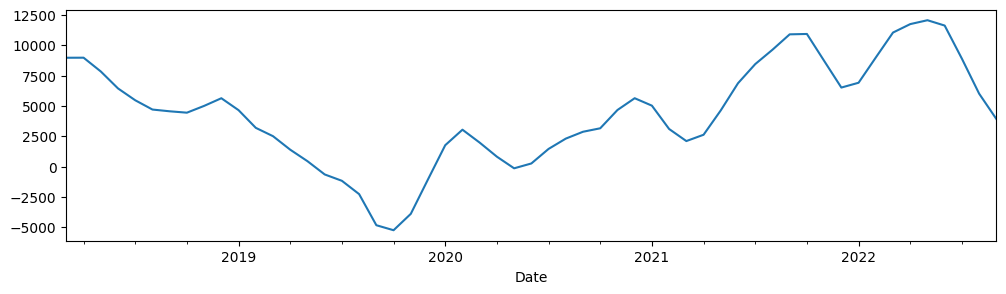

In [ ]:
ts_diff = ts.diff(2).dropna()
ts_diff.plot();

### `does the peaks and valleys AFTER diff mean sth??? we have a huge scale!

## Estimate Model Orders



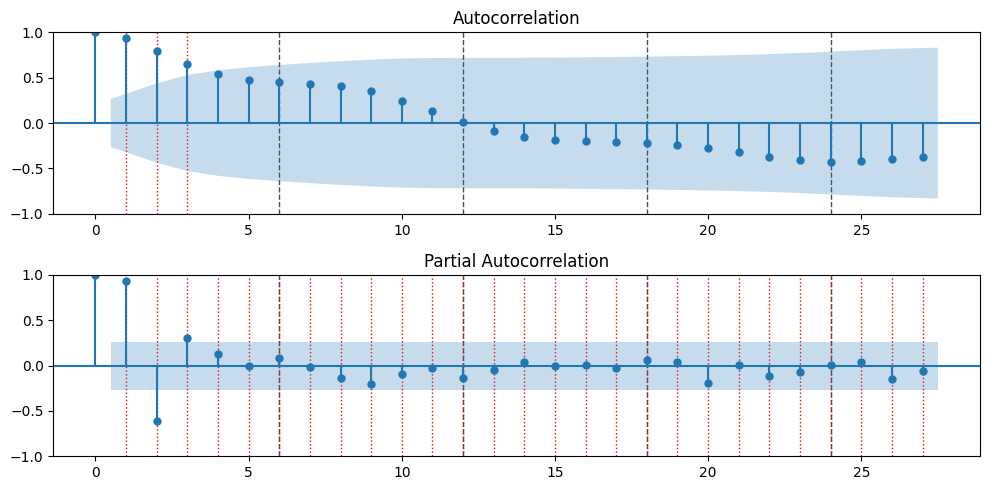

In [ ]:
plot_acf_pacf(ts_diff, nlags=27, figsize=(10, 5),
                  annotate_sig=True,annotate_seas = True,m=6);

- lag 3 in acf which is q value ~ gradually decrease
- lag 2 in pacf is p component value ~ gradually decrease p=3
- d=2
- we need to start with ARIMA model then we can decide if it's suiltable or not

After applying time series decomposition, the components show very different scales:

- **Trend component** ranges approximately between **700,000 and 750,000**, which is on the same scale as the original time series.
- **Seasonal component** fluctuates only between **-500 and 500**.
- **Residuals** vary roughly between **-2,500 and 2,500**.

Given these magnitudes, the **trend clearly dominates the behavior of the time series**.  
The seasonal component is extremely small relative to the overall variation in the data and can be considered **negligible**.  
Therefore, for modeling and interpretation purposes, **seasonality can be treated as non-existent**, and the series can be reasonably approximated as a **trend-dominated time series**.


In [ ]:
ts = ts.sort_index()


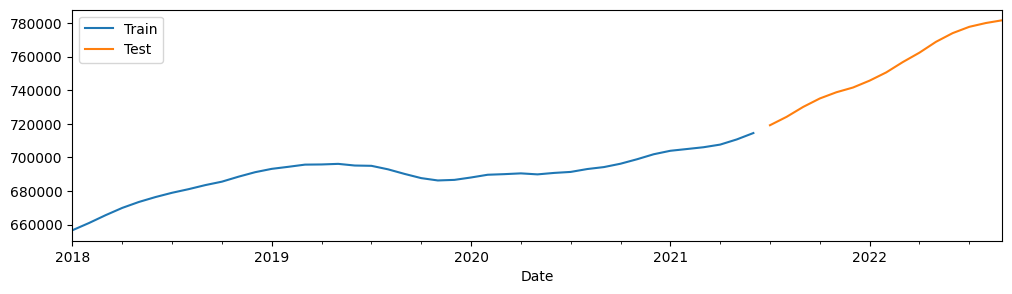

In [ ]:
train, test = train_test_split(ts, test_size=.25)
ax = train.plot(label='Train')
test.plot(ax=ax, label='Test')
ax.legend();

In [ ]:
print(ts.index.duplicated().sum())

print(ts.isnull().sum())


0
0


## Fit initial model


In [ ]:
p= 2 # AR comp
q=3 # MA comp
d=2 # differencing
arima = tsa.ARIMA(train, order=(p,d,q)).fit()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)


In [ ]:
# Obtain summary
arima.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:             Population   No. Observations:                   42
Model:                 ARIMA(2, 2, 3)   Log Likelihood                -326.251
Date:                Wed, 31 Dec 2025   AIC                            664.502
Time:                        12:21:05   BIC                            674.636
Sample:                    01-31-2018   HQIC                           668.166
                         - 06-30-2021                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2514     16.821      0.015      0.988     -32.717      33.219
ar.L2          0.5620     15.040      0.037      0.970     -28.917      30.041
ma.L1         -0.2515     16.806     -0.015      0.988     -33.191      32.688
ma.L2         -0.5583     15.037     -0.037      0.970     -30.030      28.913
ma.L3          0.0029      0.108      0.027      0.978      -0.208       0.214
sigma2      6.681e+05      0.001   1.24e+09      0.000    6.68e+05    6.68e+05
===================================================================================
Ljung-Box (L1) (Q):                   0.04   Jarque-Bera (JB):                 0.50
Prob(Q):                              0.83   Prob(JB):                         0.78
Heteroskedasticity (H):               4.04   Skew:                            -0.08
Prob(H) (two-sided):                  0.02   Kurtosis:                         2.48
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 7.18e+25. Standard errors may be unstable.
"""

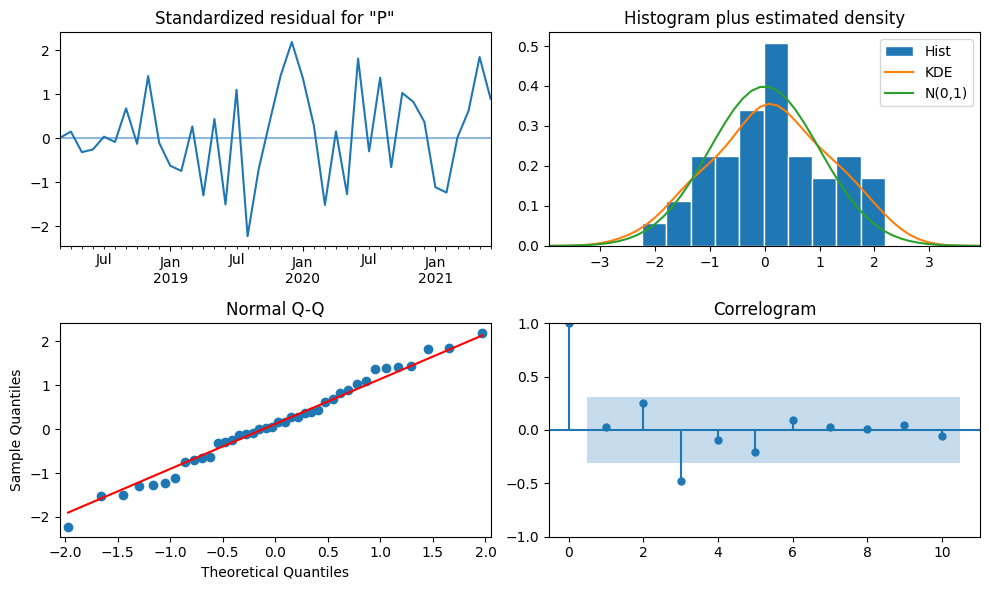

In [ ]:
# Obtain diagnostic plots
fig = arima.plot_diagnostics()
fig.set_size_inches(10,6)
fig.tight_layout()

The diagnostic plots indicate that the model assumptions are largely satisfied.

The histogram of the residuals shows a roughly symmetric distribution with no noticeable skewness, suggesting that the residuals are centered around zero.  
The standardized residuals plot does not exhibit extreme spikes or systematic patterns, indicating stable variance and the absence of influential outliers.

The normal Q–Q plot shows that most residuals lie close to the reference line, supporting the assumption of approximate normality.

Finally, the correlogram of the residuals reveals that nearly all autocorrelations fall within the confidence bounds, with only a single lag slightly exceeding the interval, which is statistically expected.

Overall, the residuals behave like white noise, suggesting that the model adequately captures the underlying structure of the time series and no significant information remains unexplained.


### evaluate arima

------------------------------------------------------------
Regression Metrics: 
------------------------------------------------------------
- MAE = 7,319.679
- MSE = 69,690,222.126
- RMSE = 8,348.067
- R^2 = 0.830
- MAPE = 0.96%


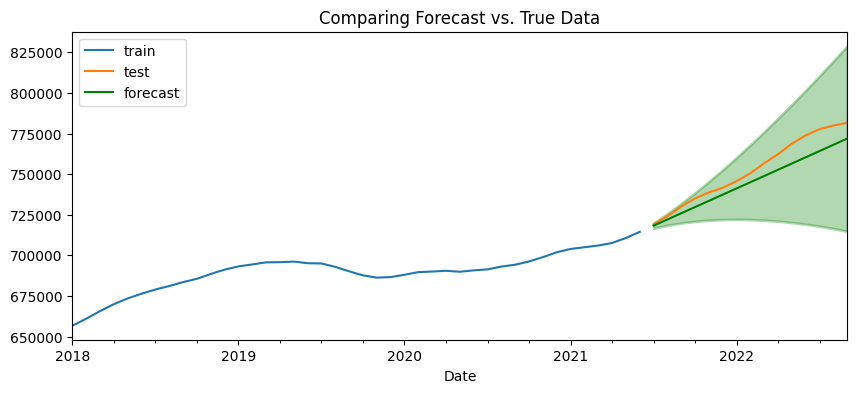

In [ ]:
# Obtain forecast as a dataframe with confidence intervals
forecast_df = arima.get_forecast(steps=len(test)).summary_frame()
# Call the custom function to plot the forecasts with confidence intervals and true values
plot_forecast(train, test, forecast_df);
# Obtain metrics
regression_metrics_ts(test, forecast_df['mean'])

The regression metrics indicate strong model performance.

- The MAE of 7,319 and RMSE of 8,348 indicate that the model’s predictions typically deviate from the true values by approximately ±7–8 thousand units.  

- Given that the original time series values range between 700,000 and 750,000, this corresponds to an error of about 1% above or below the actual values.

- The R² value of 0.83 shows that the model explains 83% of the variance in the data.  

- The MAPE of 0.96% further confirms that, on average, the model’s forecasts differ from the true values by less than 1%.

Together with the diagnostic results, these metrics indicate that the model provides accurate and reliable forecasts.



### Tune with pmdarima's auto_arima


In [ ]:
# Default auto_arima will select model based on AIC score
auto_model = pm.auto_arima(
    train,
    seasonal=False,
    d=2,
    trace=True,
    error_action='ignore',
)

Performing stepwise search to minimize aic
 ARIMA(2,2,2)(0,0,0)[0] intercept   : AIC=666.318, Time=0.22 sec
 ARIMA(0,2,0)(0,0,0)[0] intercept   : AIC=658.418, Time=0.02 sec
 ARIMA(1,2,0)(0,0,0)[0] intercept   : AIC=660.256, Time=0.03 sec
 ARIMA(0,2,1)(0,0,0)[0] intercept   : AIC=660.322, Time=0.06 sec
 ARIMA(0,2,0)(0,0,0)[0]             : AIC=656.427, Time=0.02 sec
 ARIMA(1,2,1)(0,0,0)[0] intercept   : AIC=662.484, Time=0.07 sec

Best model:  ARIMA(0,2,0)(0,0,0)[0]          
Total fit time: 0.420 seconds


In [ ]:
# the auto_arima will store our best nonseasonal and seasonal orders separtely
print(auto_model.order)

(0, 2, 0)


### Question: - p=0, d=2, q=0? no q no p no seasonality which kind of model is???

In [ ]:
# Obtain summary of the best model from auto_arima
auto_model.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                   42
Model:               SARIMAX(0, 2, 0)   Log Likelihood                -327.213
Date:                Wed, 31 Dec 2025   AIC                            656.427
Time:                        12:21:07   BIC                            658.116
Sample:                    01-31-2018   HQIC                           657.037
                         - 06-30-2021                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2      7.446e+05   2.07e+05      3.592      0.000    3.38e+05    1.15e+06
===================================================================================
Ljung-Box (L1) (Q):                   0.26   Jarque-Bera (JB):                 0.87
Prob(Q):                              0.61   Prob(JB):                         0.65
Heteroskedasticity (H):               2.66   Skew:                             0.06
Prob(H) (two-sided):                  0.09   Kurtosis:                         2.29
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

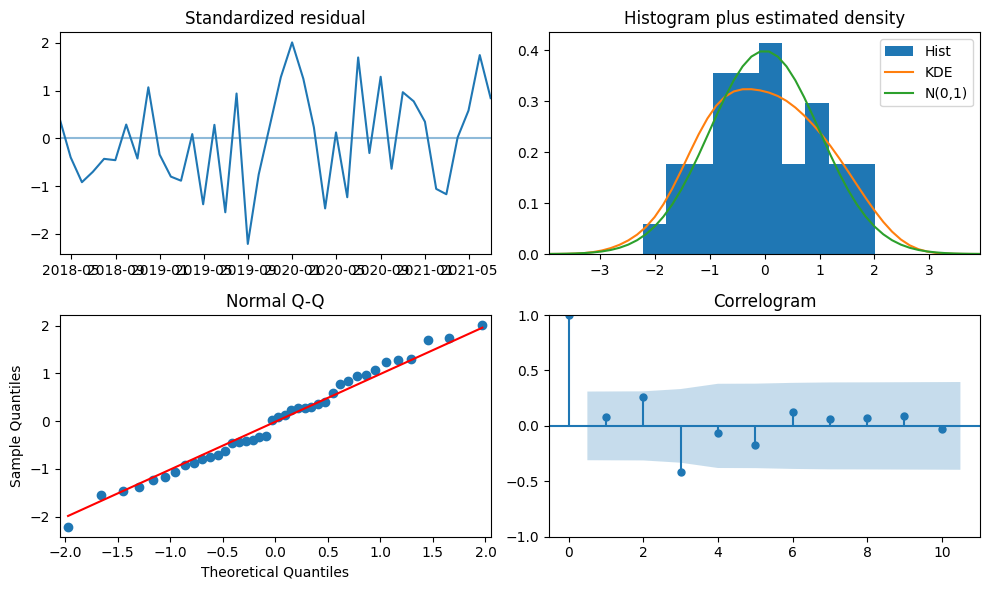

In [ ]:
# Obtain diagnostic plots
fig = auto_model.plot_diagnostics()
fig.set_size_inches(10,6)
fig.tight_layout()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)


------------------------------------------------------------
Regression Metrics: 
------------------------------------------------------------
- MAE = 7,492.333
- MSE = 73,224,450.200
- RMSE = 8,557.129
- R^2 = 0.822
- MAPE = 0.98%


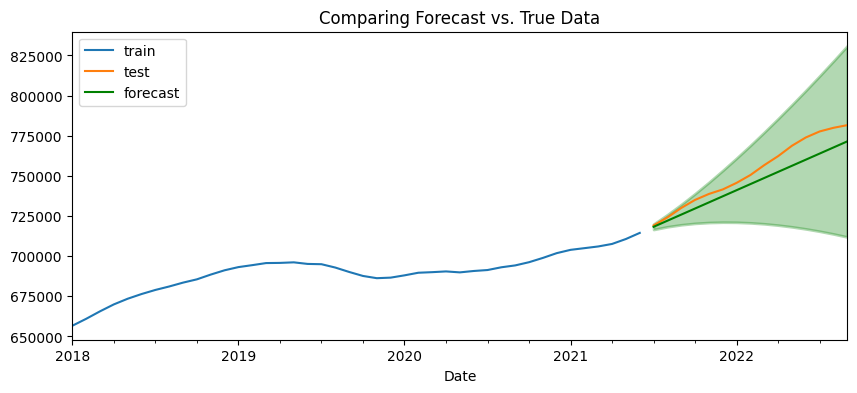

In [ ]:
best_order = auto_model.order
sm_model = tsa.ARIMA(train, order=best_order).fit()   # استخدمي best_order
forecast2_df = sm_model.get_forecast(steps=len(test)).summary_frame()  # استخدمي sm_model
plot_forecast(train, test, forecast2_df)
regression_metrics_ts(test, forecast2_df['mean'])

After tuning the model, the performance remains strong and stable.

- The MAE of 7,492 and RMSE of 8,557 indicate that predictions typically deviate from the true values by approximately ±7–9 thousand units.  
Given the scale of the time series (around 700,000–750,000), this corresponds to an average error of roughly 1%.

- R^2: The model explains 82.2% of the variance in the data, as indicated by the R² value of 0.822.  

- The MAPE of 0.98% confirms that, on average, forecasts differ from actual values by less than 1%.

Overall, the tuned model maintains high predictive accuracy and provides reliable forecasts.

Although hyperparameter tuning was applied, the pre-tuned model achieved slightly better performance across all evaluation metrics, including lower MAE, RMSE, and MAPE, as well as a higher R² value.

Since both models satisfy the diagnostic assumptions and no significant improvement was obtained through tuning, the pre-tuned model was selected as the final model due to its superior accuracy and simpler configuration.


### Ques: the gap between the training line and the testing one what it mean?

`steps` is a keyword to predict after thr training and testing data???

- Make true future forecasts using the entire dataset (for dates beyond the entire ts).
- Calculate the predicted net change in home value for the forecasted period as both:
- Raw values for change in the final month in the forecast vs. the first month.
- Convert the raw delta into a percent change.

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

#use manual model for future forecast
final_model = SARIMAX(
    ts,
    order=(3,2,3),

   # seasonal_order=(1,0,1,12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

final_results = final_model.fit()

future_forecast = final_results.forecast(steps=6)
future_forecast

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)


,predicted_mean
2022-10-31,783471.352118
2022-11-30,786003.649704
2022-12-31,789100.226387
2023-01-31,792438.832698
2023-02-28,795629.374444
2023-03-31,798540.862985


In [ ]:
n_forecast = 6  # num of new months
future_forecast = sm_model.get_forecast(steps=n_forecast).summary_frame()


In [ ]:
start_value = future_forecast['mean'].iloc[0]
end_value = future_forecast['mean'].iloc[-1]

raw_delta = end_value - start_value
print(f"Predicted raw change over {n_forecast} months: ${raw_delta:,.2f}")


Predicted raw change over 6 months: $19,005.00


In [ ]:
percent_change = (raw_delta / start_value) * 100
print(f"Predicted percent change over {n_forecast} months: {percent_change:.2f}%")


Predicted percent change over 6 months: 2.65%


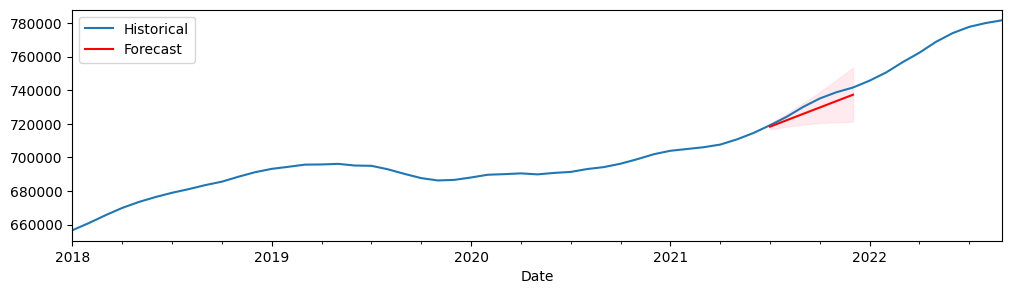

In [ ]:
import matplotlib.pyplot as plt

# رسم البيانات الأصلية
ax = ts.plot(label='Historical')

# إضافة التوقعات المستقبلية
future_forecast['mean'].plot(ax=ax, label='Forecast', color='red')
plt.fill_between(future_forecast.index,
                 future_forecast['mean_ci_lower'], #lowest limit for the predicted number
                 future_forecast['mean_ci_upper'], # highest limit may happen
                 color='pink', alpha=0.3)
plt.legend()
plt.show()


# seasonality model:
i'll try using a seasonal model just to see how the result would change, (also regarding to the assingment name i think that i may use a seasonal model to enhance how it works)

## Seasonality


lets estimate the model order with seasonality order

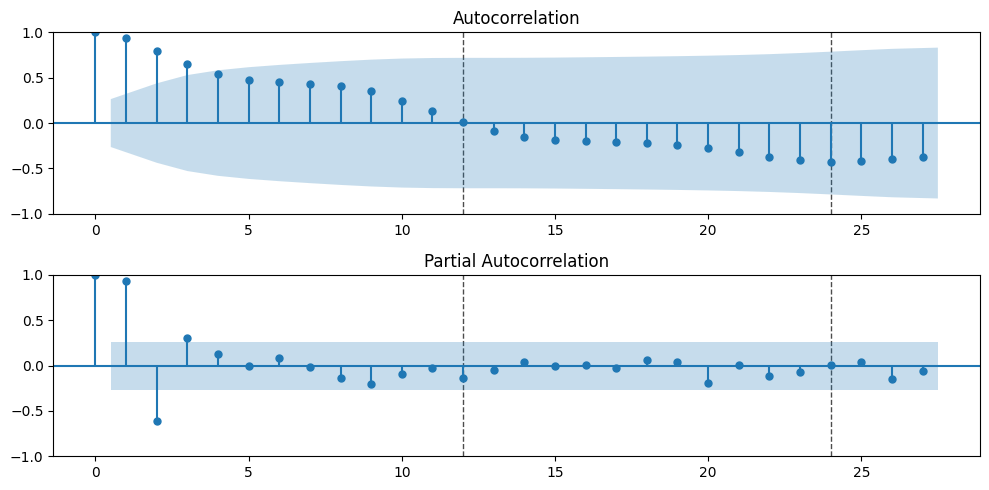

In [ ]:
# now look at the acf/pacf of the stationary data
plot_acf_pacf(ts_diff, annotate_seas = True, m = 12, nlags = 27);

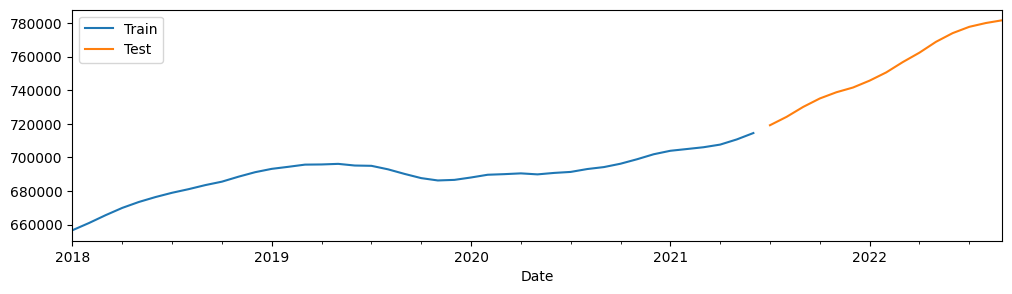

In [ ]:
# tts
train, test = train_test_split(ts, test_size=.25)
ax = train.plot(label='Train')
test.plot(ax=ax, label='Test')
ax.legend();

In [ ]:
# Orders for non seasonal components
p = 3  # nonseasonal AR
d = 2  # nonseasonal differencing
q = 3  # nonseasonal MA

# Orders for seasonal components
P = 1  # Seasonal AR
D = 0  # Seasonal differencing
Q = 1  # Seasonal MA
m = 12 # Seasonal period

sarima = tsa.ARIMA(train, order = (p,d,q), seasonal_order=(P,D,Q,m)).fit()

# Obtain summary
sarima.summary()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                         Population   No. Observations:                   42
Model:             ARIMA(3, 2, 3)x(1, 0, [1], 12)   Log Likelihood                -326.393
Date:                            Wed, 31 Dec 2025   AIC                            670.785
Time:                                    12:21:11   BIC                            685.985
Sample:                                01-31-2018   HQIC                           676.281
                                     - 06-30-2021                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2042      7.908      0.026      0.979     -15.296      15.704
ar.L2          0.4378      7.372      0.059      0.953     -14.011      14.887
ar.L3          0.1662      4.800      0.035      0.972      -9.241       9.573
ma.L1         -0.2048      7.955     -0.026      0.979     -15.796      15.386
ma.L2         -0.4342      7.390     -0.059      0.953     -14.918      14.050
ma.L3         -0.1628      4.823     -0.034      0.973      -9.615       9.289
ar.S.L12       0.2916      2.091      0.139      0.889      -3.806       4.389
ma.S.L12      -0.2896      2.095     -0.138      0.890      -4.395       3.816
sigma2      5.959e+05      0.000   2.31e+09      0.000    5.96e+05    5.96e+05
===================================================================================
Ljung-Box (L1) (Q):                   0.03   Jarque-Bera (JB):                 0.46
Prob(Q):                              0.87   Prob(JB):                         0.79
Heteroskedasticity (H):               4.33   Skew:                            -0.07
Prob(H) (two-sided):                  0.01   Kurtosis:                         2.49
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 8.79e+26. Standard errors may be unstable.
"""

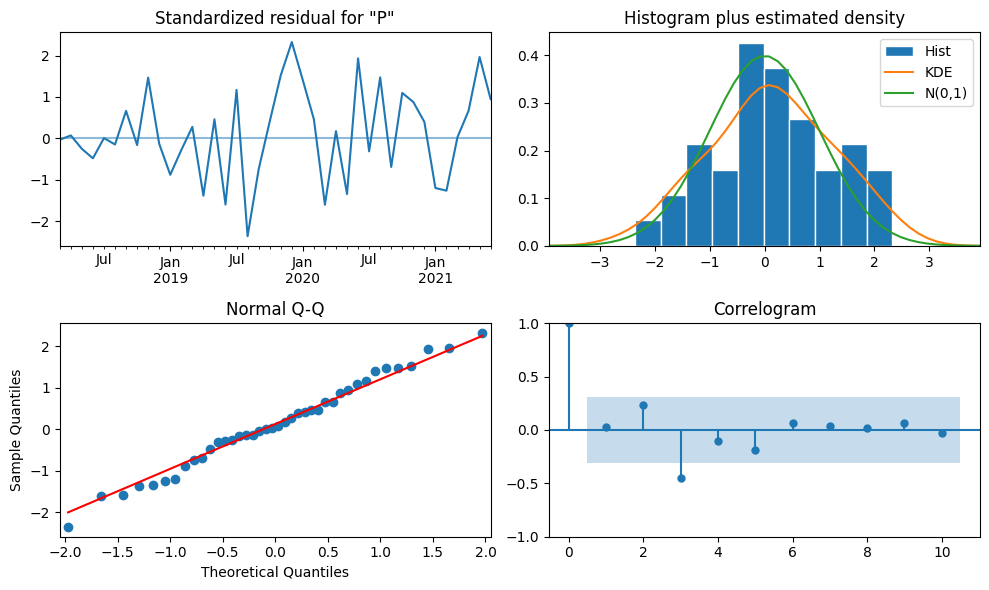

In [ ]:
# Obtain diagnostic plots
fig = sarima.plot_diagnostics()
fig.set_size_inches(10,6)
fig.tight_layout()

------------------------------------------------------------
Regression Metrics: 
------------------------------------------------------------
- MAE = 7,397.396
- MSE = 71,293,105.693
- RMSE = 8,443.524
- R^2 = 0.826
- MAPE = 0.97%


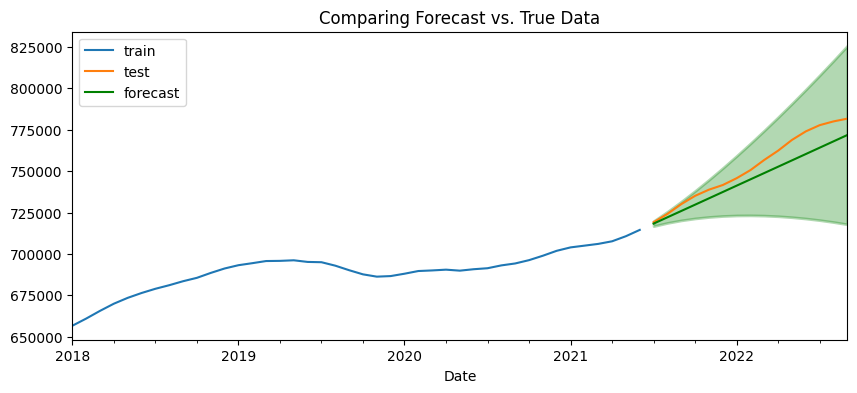

In [ ]:
# Obtain forecast as a dataframe with confidence intervals
forecast_df = sarima.get_forecast(steps=len(test)).summary_frame()
# Call the custom function to plot the forecasts with confidence intervals and true values
plot_forecast(train, test, forecast_df);
# Obtain metrics
regression_metrics_ts(test, forecast_df['mean'])

The regression metrics indicate strong performance for the seasonal model.

- The MAE of 7,397 and RMSE of 8,444 indicate that the model’s predictions typically deviate from the true values by approximately ±7–8 thousand units.  
Given that the original time series values lie around 700,000–750,000, this corresponds to an average error of roughly 1%.

- The R² value of 0.826 shows that the model explains 82.6% of the variance in the data.  
- The MAPE of 0.97% further confirms that, on average, the model’s forecasts differ from the actual values by less than 1%.

Overall, the seasonal model provides accurate forecasts; however, its performance is comparable to the non-seasonal model, indicating that seasonality does not contribute significant additional explanatory power.


In [ ]:
import pmdarima as pm

# Default auto_arima will select model based on AIC score
auto_model = pm.auto_arima(
    train,
    seasonal=True,
    m=12,
    trace=True
)

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[12] intercept   : AIC=768.432, Time=0.61 sec
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=733.235, Time=0.02 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=872.953, Time=0.13 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=734.033, Time=0.17 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=751.534, Time=0.02 sec
 ARIMA(0,1,0)(1,0,0)[12] intercept   : AIC=735.153, Time=0.07 sec
 ARIMA(0,1,0)(0,0,1)[12] intercept   : AIC=735.153, Time=0.07 sec
 ARIMA(0,1,0)(1,0,1)[12] intercept   : AIC=737.169, Time=0.34 sec
 ARIMA(1,1,0)(0,0,0)[12] intercept   : AIC=740.880, Time=0.17 sec
 ARIMA(0,1,1)(0,0,0)[12] intercept   : AIC=734.901, Time=0.09 sec
 ARIMA(1,1,1)(0,0,0)[12] intercept   : AIC=745.401, Time=0.65 sec

Best model:  ARIMA(0,1,0)(0,0,0)[12] intercept
Total fit time: 2.361 seconds


In [ ]:
# the auto_arima will store our best nonseasonal and seasonal orders separtely
print(auto_model.order)
print(auto_model.seasonal_order)

(0, 1, 0)
(0, 0, 0, 12)


In [ ]:
# Obtain summary of the best model from auto_arima
auto_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                   42
Model:               SARIMAX(0, 1, 0)   Log Likelihood                -364.617
Date:                Wed, 31 Dec 2025   AIC                            733.235
Time:                        12:21:15   BIC                            736.662
Sample:                    01-31-2018   HQIC                           734.483
                         - 06-30-2021                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept   1409.9268    290.500      4.853      0.000     840.557    1979.297
sigma2      3.104e+06   7.44e+05      4.170      0.000    1.65e+06    4.56e+06
===================================================================================
Ljung-Box (L1) (Q):                  30.16   Jarque-Bera (JB):                 1.35
Prob(Q):                              0.00   Prob(JB):                         0.51
Heteroskedasticity (H):               0.45   Skew:                            -0.44
Prob(H) (two-sided):                  0.14   Kurtosis:                         2.89
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

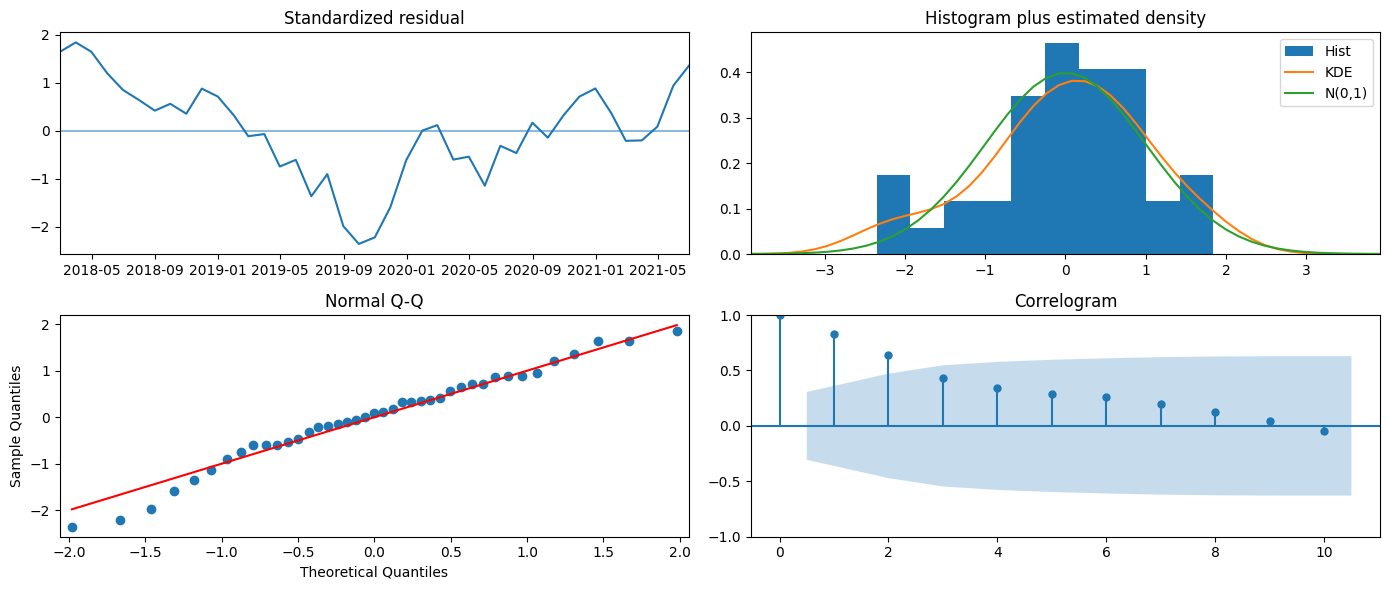

In [ ]:
# Obtain diagnostic plots
fig = auto_model.plot_diagnostics()
fig.set_size_inches(14,6)
fig.tight_layout()

There is still a significant value in the correlogram of the residuals at lag 2,1.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)


------------------------------------------------------------
Regression Metrics: 
------------------------------------------------------------
- MAE = 37,900.333
- MSE = 1,846,971,743.000
- RMSE = 42,976.409
- R^2 = -3.499
- MAPE = 4.97%


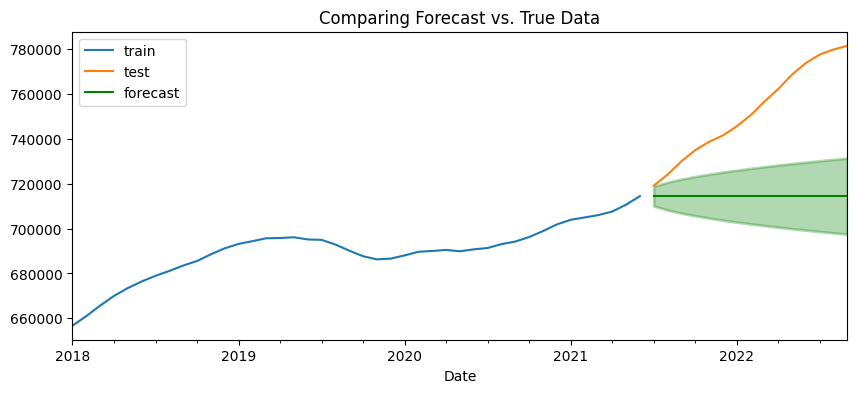

In [ ]:
# Use auto_arima parameters to fit an ARIMA
auto_model = tsa.ARIMA(
    train, order=auto_model.order, seasonal_order=auto_model.seasonal_order
).fit()


# Obtain forecast as a dataframe with confidence intervals
forecast_df = auto_model.get_forecast(steps=len(test)).summary_frame()
# Call the custom function to plot the forecasts with confidence intervals and true values
plot_forecast(train, test, forecast_df);
# Obtain metrics
regression_metrics_ts(test, forecast_df['mean'])

#### Ques: a very small mape comparing to a negative r^2 how can i trust this model??

The regression metrics indicate poor model performance after tuning.

- The MAE of 37,900 and RMSE of 42,976 show that the model’s predictions typically deviate from the true values by approximately ±38–43 thousand units.  
Relative to the original time series scale (around 700,000–750,000), this corresponds to an error of approximately 5%.

- The negative R² value (-3.499) indicates that the model performs substantially worse than a naive baseline that simply predicts the mean of the data.  
This suggests that the tuned model fails to capture the underlying structure of the time series.

- The MAPE of 4.97% further confirms the degradation in predictive accuracy following tuning.

Overall, hyperparameter tuning significantly deteriorated model performance, and this model is therefore unsuitable for forecasting.


This result reinforces the conclusion that introducing or tuning seasonal components is unnecessary and detrimental for this dataset.